In [ ]:
#Connect Google Drive
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#Access files
from pathlib import Path

PROJECT_DIR = Path('/content/drive/MyDrive/FPT AI Intern Prep/CV OCR Project')
INPUT_DIR = PROJECT_DIR / 'input_images'
OUTPUT_DIR = PROJECT_DIR / 'output_images'

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Input folder:", INPUT_DIR)
print("Output folder:", OUTPUT_DIR)
print("Input images:", list(INPUT_DIR.glob('*')))

Input folder: /content/drive/MyDrive/FPT AI Intern Prep/CV OCR Project/input_images
Output folder: /content/drive/MyDrive/FPT AI Intern Prep/CV OCR Project/output_images
Input images: [PosixPath('/content/drive/MyDrive/FPT AI Intern Prep/CV OCR Project/input_images/clear_01.jpg'), PosixPath('/content/drive/MyDrive/FPT AI Intern Prep/CV OCR Project/input_images/clear_02.jpg'), PosixPath('/content/drive/MyDrive/FPT AI Intern Prep/CV OCR Project/input_images/clear_03.jpg'), PosixPath('/content/drive/MyDrive/FPT AI Intern Prep/CV OCR Project/input_images/tilted_01.jpg'), PosixPath('/content/drive/MyDrive/FPT AI Intern Prep/CV OCR Project/input_images/tilted_02.jpg'), PosixPath('/content/drive/MyDrive/FPT AI Intern Prep/CV OCR Project/input_images/tilted_03.jpg'), PosixPath('/content/drive/MyDrive/FPT AI Intern Prep/CV OCR Project/input_images/blur_01.jpg'), PosixPath('/content/drive/MyDrive/FPT AI Intern Prep/CV OCR Project/input_images/dark_01.jpg'), PosixPath('/content/drive/MyDrive/FPT 

In [ ]:
#Import CV
import cv2
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

print("OpenCV version:", cv2.__version__)

OpenCV version: 4.13.0


Image shape: (202, 352, 3)


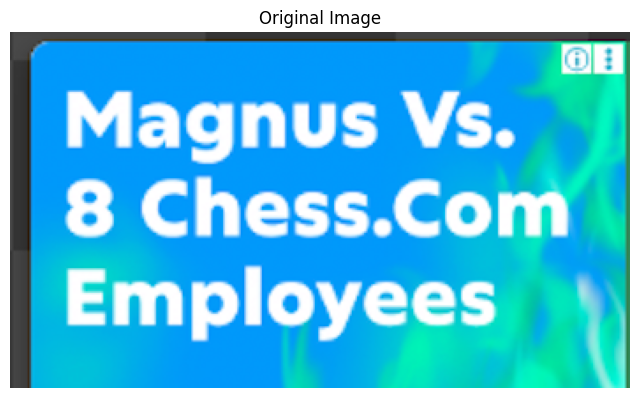

In [ ]:
#Read a file
image_path = INPUT_DIR / 'noisybg_01.jpg'

image_bgr = cv2.imread(str(image_path))

if image_bgr is None:
    raise FileNotFoundError(f"Cant read the image bro: {image_path}")

image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

print("Image shape:", image_rgb.shape)

plt.figure(figsize=(8, 5))
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis("off")
plt.show()

Original shape: (202, 352, 3)
Resized shape: (202, 352, 3)


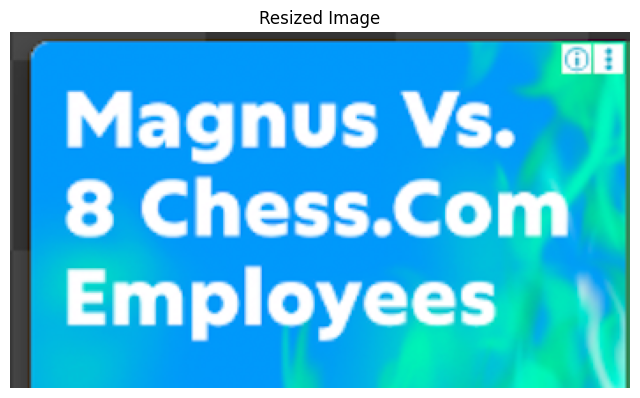

In [ ]:
#Resize image
def resize_image(image, target_width=1000):
    height, width = image.shape[:2]

    if width <= target_width:
        return image

    scale = target_width / width
    new_height = int(height * scale)

    return cv2.resize(image, (target_width, new_height))

resized_rgb = resize_image(image_rgb)

print("Original shape:", image_rgb.shape)
print("Resized shape:", resized_rgb.shape)

plt.figure(figsize=(8, 5))
plt.imshow(resized_rgb)
plt.title("Resized Image")
plt.axis("off")
plt.show()

Grayscale shape: (202, 352)


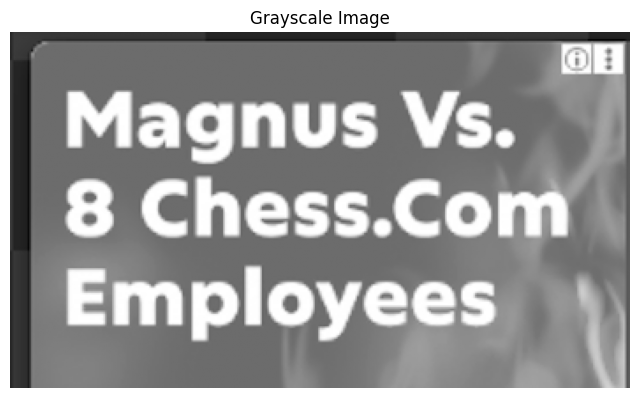

In [ ]:
#Greyscale
resized_bgr = cv2.cvtColor(resized_rgb, cv2.COLOR_RGB2BGR)
gray = cv2.cvtColor(resized_bgr, cv2.COLOR_BGR2GRAY)

print("Grayscale shape:", gray.shape)

plt.figure(figsize=(8, 5))
plt.imshow(gray, cmap='gray')
plt.title("Grayscale Image")
plt.axis("off")
plt.show()

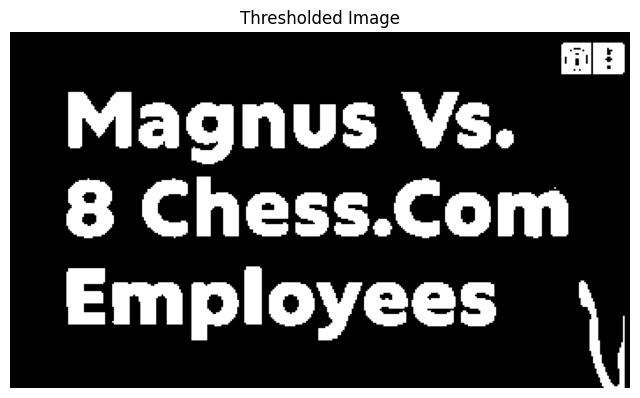

In [ ]:
#Thresholding
_, thresholded = cv2.threshold(
    gray,
    0,
    255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

plt.figure(figsize=(8, 5))
plt.imshow(thresholded, cmap='gray')
plt.title("Thresholded Image")
plt.axis("off")
plt.show()

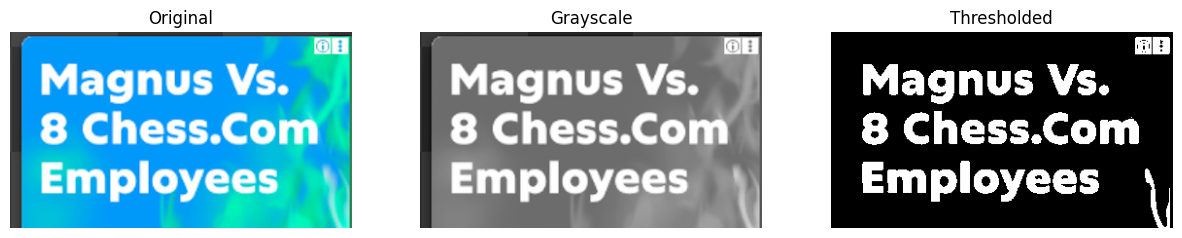

In [ ]:
#Observe

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(resized_rgb)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(gray, cmap='gray')
plt.title("Grayscale")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(thresholded, cmap='gray')
plt.title("Thresholded")
plt.axis("off")

plt.show()

In [ ]:
from pathlib import Path
import cv2
import matplotlib.pyplot as plt
import pandas as pd

# Đúng theo tên folder hiện tại của bạn
PROJECT_DIR = Path('/content/drive/MyDrive/FPT AI Intern Prep/CV OCR Project')
INPUT_DIR = PROJECT_DIR / 'input_images'
OUTPUT_DIR = PROJECT_DIR / 'output_images'

# Tách output thành 2 folder cho gọn
GRAY_DIR = OUTPUT_DIR / 'grayscale'
OTSU_DIR = OUTPUT_DIR / 'otsu_threshold'

GRAY_DIR.mkdir(parents=True, exist_ok=True)
OTSU_DIR.mkdir(parents=True, exist_ok=True)

# Kiểm tra toàn bộ ảnh input
image_files = sorted([
    path for path in INPUT_DIR.glob('*')
    if path.suffix.lower() in ['.jpg', '.jpeg', '.png']
])

print(f"Found {len(image_files)} inputs:")
for path in image_files:
    print("-", path.name)

print("\nOutput grayscale here:", GRAY_DIR)
print("Output threshold here:", OTSU_DIR)

Found 10 inputs:
- blur_01.jpg
- clear_01.jpg
- clear_02.jpg
- clear_03.jpg
- dark_01.jpg
- noisybg_01.jpg
- noisybg_02.png
- tilted_01.jpg
- tilted_02.jpg
- tilted_03.jpg

Output grayscale here: /content/drive/MyDrive/FPT AI Intern Prep/CV OCR Project/output_images/grayscale
Output threshold here: /content/drive/MyDrive/FPT AI Intern Prep/CV OCR Project/output_images/otsu_threshold


In [ ]:
#Preprocess 1 image

def preprocess_image(image_path: Path, target_width: int = 1000):
    image_bgr = cv2.imread(str(image_path))

    if image_bgr is None:
        raise FileNotFoundError(f"Cant read: {image_path}")

    original_height, original_width = image_bgr.shape[:2]

    if original_width > target_width:
        scale = target_width / original_width
        new_height = int(original_height * scale)
        image_bgr = cv2.resize(
            image_bgr,
            (target_width, new_height),
            interpolation=cv2.INTER_AREA
        )


    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

    gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)

    threshold_value, otsu_image = cv2.threshold(
        gray,
        0,
        255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    gray_path = GRAY_DIR / f"{image_path.stem}_gray.png"
    otsu_path = OTSU_DIR / f"{image_path.stem}_otsu.png"

    cv2.imwrite(str(gray_path), gray)
    cv2.imwrite(str(otsu_path), otsu_image)

    return {
        "filename": image_path.name,
        "original": image_rgb,
        "gray": gray,
        "otsu": otsu_image,
        "original_shape": (original_height, original_width),
        "processed_shape": gray.shape,
        "threshold_value": threshold_value,
        "gray_file": gray_path.name,
        "otsu_file": otsu_path.name
    }

In [ ]:
#Process Now
results = []

for image_path in image_files:
    result = preprocess_image(image_path)
    results.append(result)
    print(f"Preprocessed: {result['filename']}")

print(f"\nCOMPLETED: {len(results)}/{len(image_files)} pics.")

Preprocessed: blur_01.jpg
Preprocessed: clear_01.jpg
Preprocessed: clear_02.jpg
Preprocessed: clear_03.jpg
Preprocessed: dark_01.jpg
Preprocessed: noisybg_01.jpg
Preprocessed: noisybg_02.png
Preprocessed: tilted_01.jpg
Preprocessed: tilted_02.jpg
Preprocessed: tilted_03.jpg

COMPLETED: 10/10 pics.


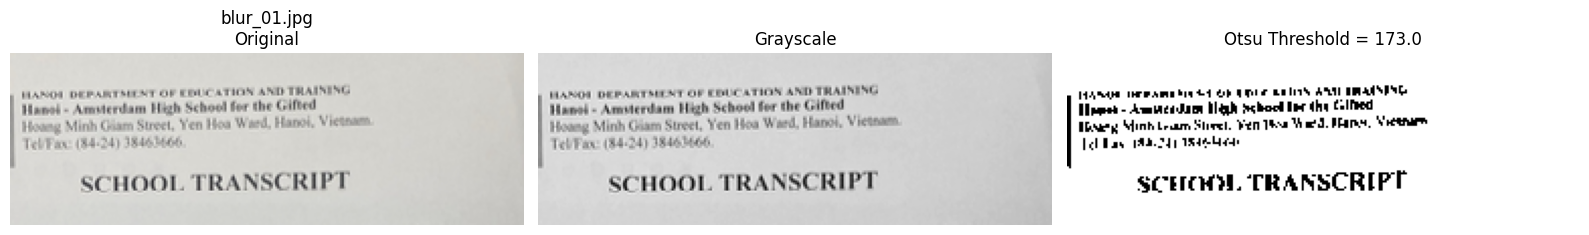

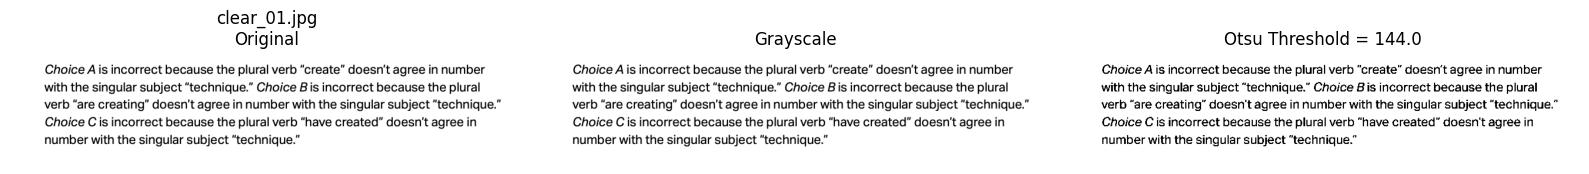

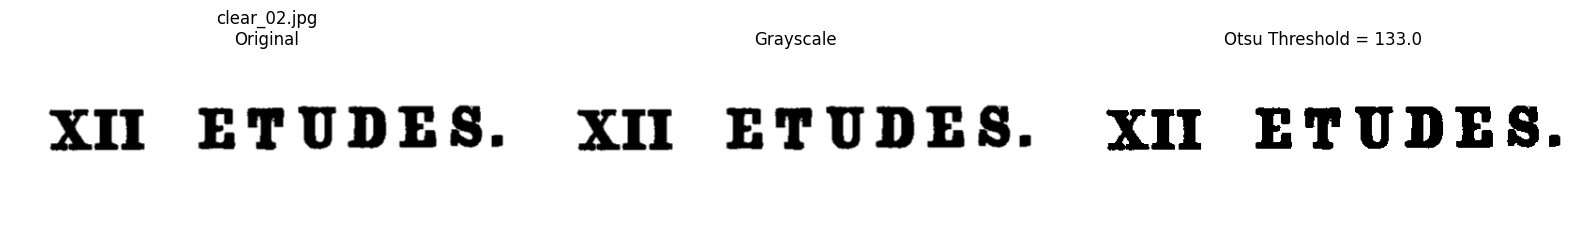

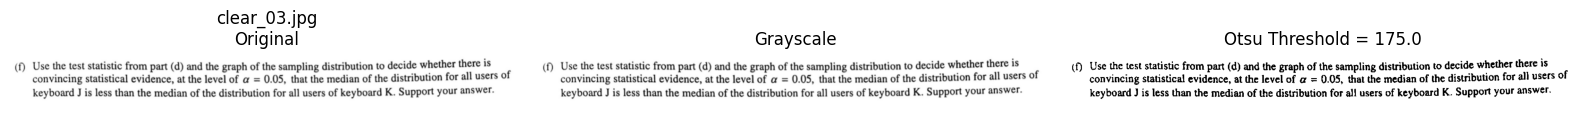

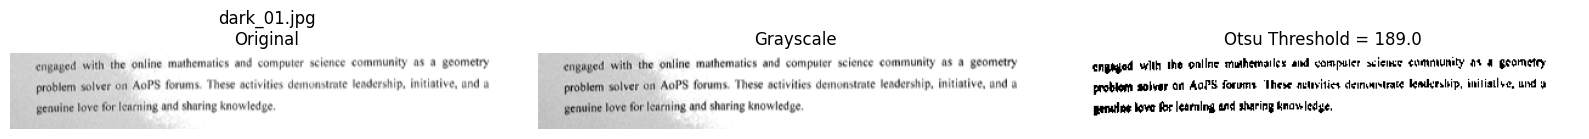

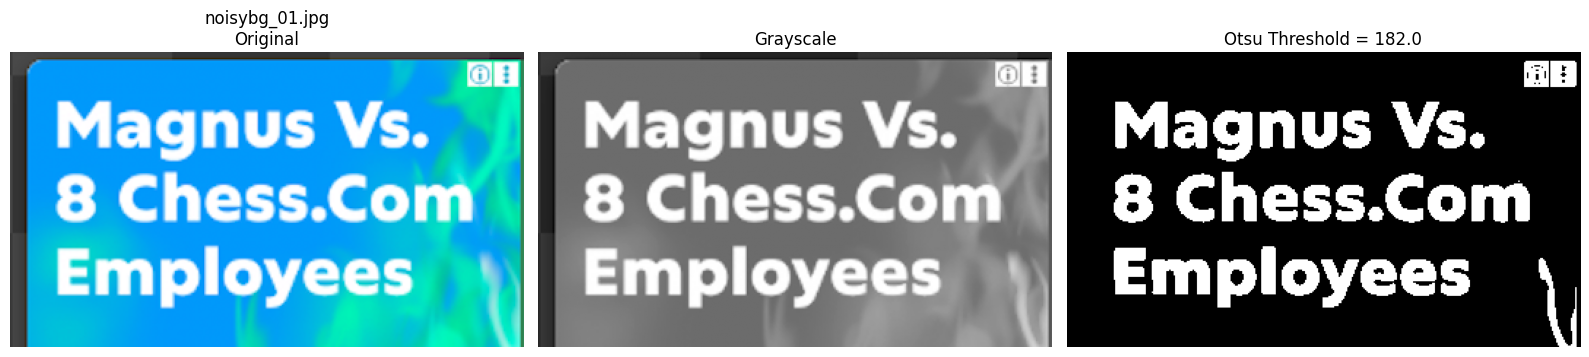

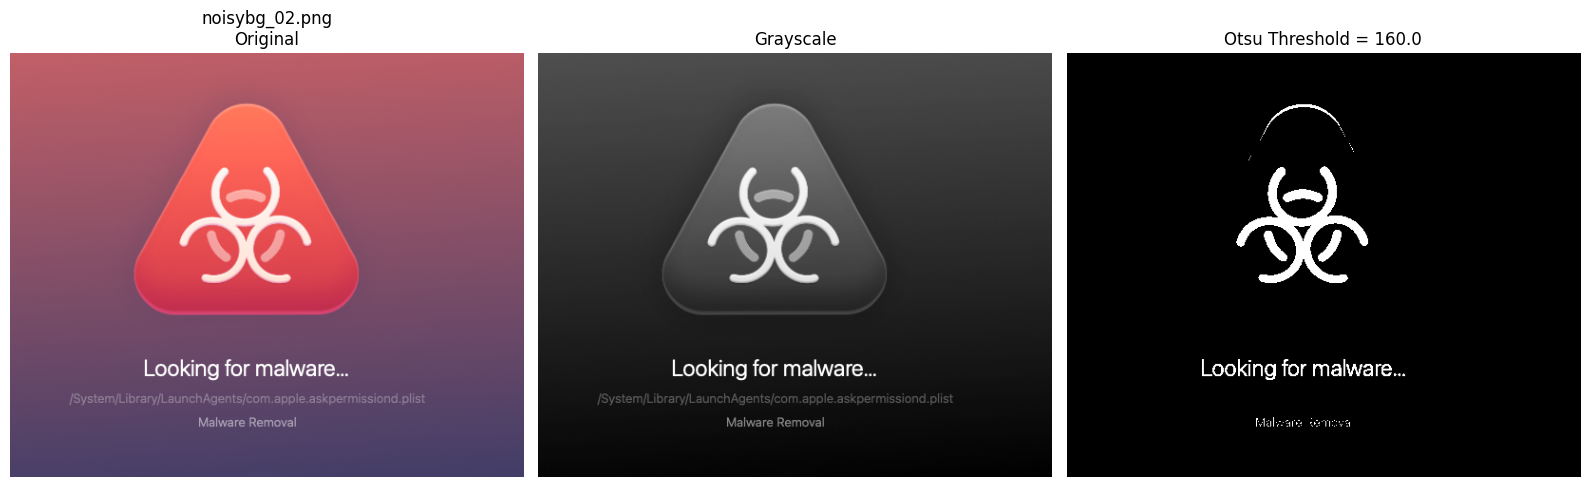

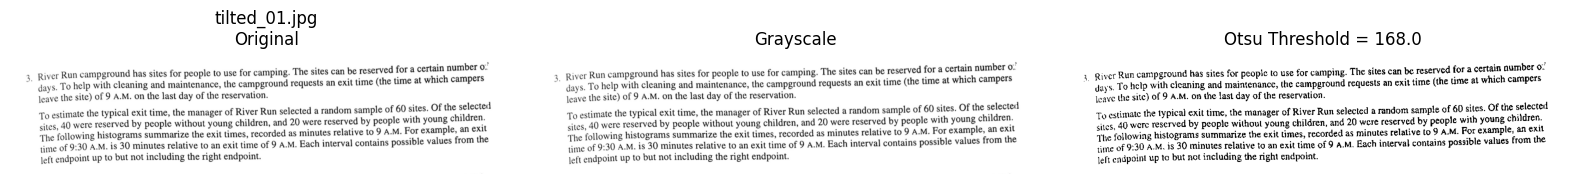

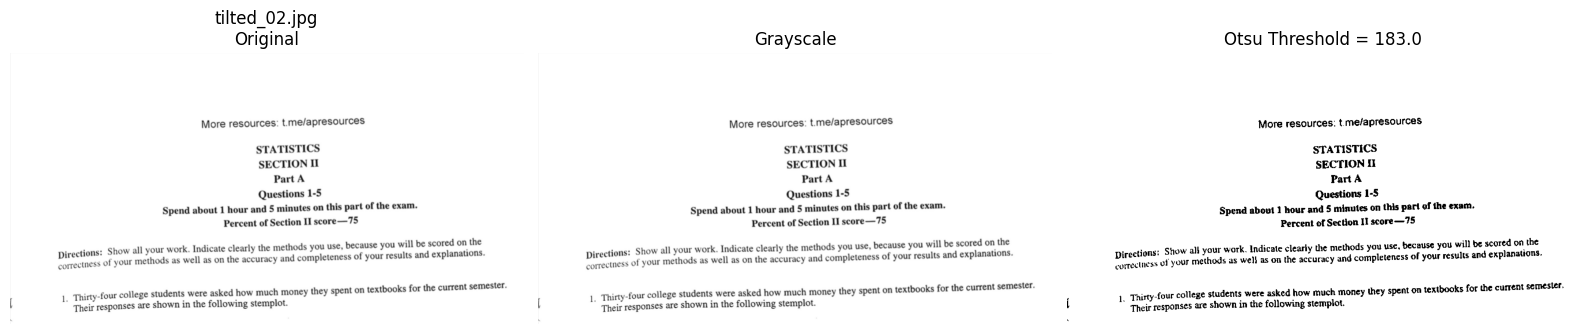

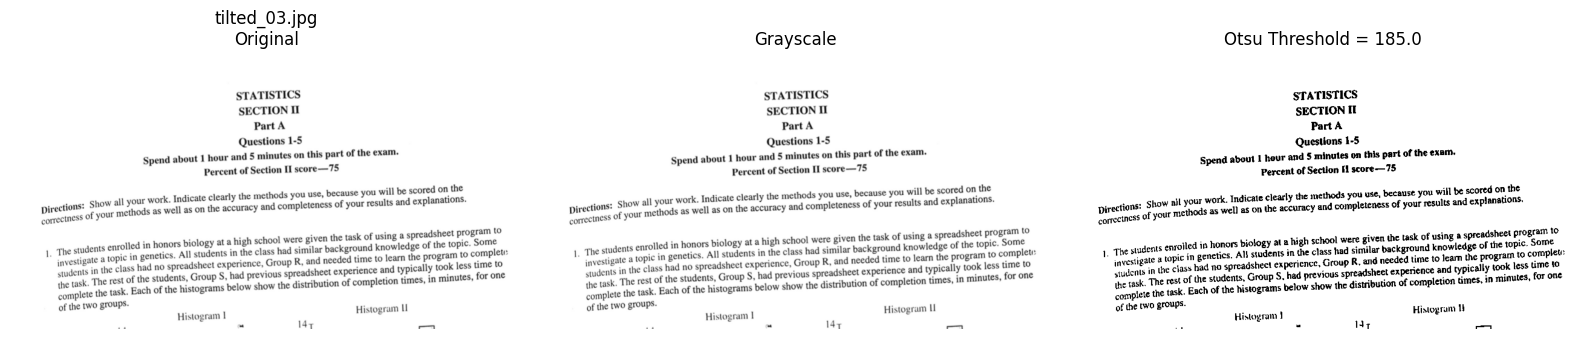

In [ ]:
#Show pic
for result in results:
    plt.figure(figsize=(16, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(result["original"])
    plt.title(f"{result['filename']}\nOriginal")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(result["gray"], cmap="gray")
    plt.title("Grayscale")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(result["otsu"], cmap="gray")
    plt.title(f"Otsu Threshold = {result['threshold_value']:.1f}")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

In [ ]:
#Result
def infer_image_type(filename: str) -> str:
    if filename.startswith("clear"):
        return "Clear"
    if filename.startswith("tilted"):
        return "Tilted"
    if filename.startswith("dark"):
        return "Dark"
    if filename.startswith("blur"):
        return "Blurred"
    if filename.startswith("noisybg"):
        return "Noisy Background"
    return "Other"

summary_df = pd.DataFrame([
    {
        "Image Name": result["filename"],
        "Image Type": infer_image_type(result["filename"]),
        "Original Shape": str(result["original_shape"]),
        "Processed Shape": str(result["processed_shape"]),
        "Otsu Threshold": round(result["threshold_value"], 2),
        "Improved?": "",
        "Remaining Problem": "",
        "Next Processing Idea": ""
    }
    for result in results
])

summary_df

,Image Name,Image Type,Original Shape,Processed Shape,Otsu Threshold,Improved?,Remaining Problem,Next Processing Idea
0,blur_01.jpg,Blurred,"(85, 254)","(85, 254)",173.0,,,
1,clear_01.jpg,Clear,"(190, 874)","(190, 874)",144.0,,,
2,clear_02.jpg,Clear,"(178, 548)","(178, 548)",133.0,,,
3,clear_03.jpg,Clear,"(123, 1061)","(115, 1000)",175.0,,,
4,dark_01.jpg,Dark,"(63, 423)","(63, 423)",189.0,,,
5,noisybg_01.jpg,Noisy Background,"(202, 352)","(202, 352)",182.0,,,
6,noisybg_02.png,Noisy Background,"(447, 541)","(447, 541)",160.0,,,
7,tilted_01.jpg,Tilted,"(223, 943)","(223, 943)",168.0,,,
8,tilted_02.jpg,Tilted,"(471, 891)","(471, 891)",183.0,,,
9,tilted_03.jpg,Tilted,"(457, 850)","(457, 850)",185.0,,,


In [ ]:
#Save
summary_path = PROJECT_DIR / 'preprocessing_summary.csv'
summary_df.to_csv(summary_path, index=False)

print("Đã lưu bảng kết quả tại:")
print(summary_path)

Đã lưu bảng kết quả tại:
/content/drive/MyDrive/FPT AI Intern Prep/CV OCR Project/preprocessing_summary.csv


In [ ]:
#OCR download
!sudo apt-get update -qq
!sudo apt-get install -y -qq tesseract-ocr tesseract-ocr-vie
!pip install -q pytesseract

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package tesseract-ocr-vie.
(Reading database ... 118242 files and directories currently installed.)
Preparing to unpack .../tesseract-ocr-vie_1%3a4.00~git30-7274cfa-1.1_all.deb ...
Unpacking tesseract-ocr-vie (1:4.00~git30-7274cfa-1.1) ...
Setting up tesseract-ocr-vie (1:4.00~git30-7274cfa-1.1) ...


In [ ]:
#Test
import pytesseract

print("Tesseract version:")
print(pytesseract.get_tesseract_version())

Tesseract version:
4.1.1


In [ ]:
#OCR Func
import cv2
import pytesseract
import pandas as pd
from pathlib import Path

def run_ocr(image_path: Path, lang: str = "eng") -> str:

    image = cv2.imread(str(image_path))

    if image is None:
        raise FileNotFoundError(f"Cant read: {image_path}")

    text = pytesseract.image_to_string(
        image,
        lang=lang,
        config="--psm 6"
    )

    return text.strip()

In [ ]:
original_path = INPUT_DIR / "clear_01.jpg"
processed_path = OTSU_DIR / "clear_01_otsu.png"

original_text = run_ocr(original_path)
processed_text = run_ocr(processed_path)

print("===== OCR Before =====")
print(original_text)

print("\n===== OCR After =====")
print(processed_text)

===== OCR Before =====
Choice A is incorrect because the plural verb “create” doesn't agree in number
with the singular subject “technique.” Choice Bis incorrect because the plural
verb “are creating" doesn't agree in number with the singular subject “technique.”
Choice C is incorrect because the plural verb “have created” doesn't agree in
number with the singular subject “technique.”

===== OCR After =====
Choice A is incorrect because the plural verb “create” doesn't agree in number
with the singular subject “technique.” Choice Bis incorrect because the plural
verb “are creating” doesn't agree in number with the singular subject “technique.”
Choice C is incorrect because the plural verb “have created” doesn't agree in
number with the singular subject “technique.”


In [ ]:
#OCR for All
ocr_results = []

for image_path in image_files:
    processed_path = OTSU_DIR / f"{image_path.stem}_otsu.png"

    original_text = run_ocr(image_path)
    processed_text = run_ocr(processed_path)

    ocr_results.append({
        "Image Name": image_path.name,
        "Image Type": infer_image_type(image_path.name),
        "OCR Original": original_text,
        "OCR After Otsu": processed_text,
        "Better Version": "",
        "Main OCR Error": "",
        "Next Processing Idea": ""
    })

    print("=" * 80)
    print("IMAGE:", image_path.name)
    print("\n[Original OCR]")
    print(original_text)
    print("\n[After Otsu OCR]")
    print(processed_text)
    print()

ocr_df = pd.DataFrame(ocr_results)

print(f"OCR Completed {len(ocr_df)}/{len(image_files)} pics.")

IMAGE: blur_01.jpg

[Original OCR]
a

[After Otsu OCR]
| fino Rei ig wctined R
SCHOON. TRANSCRIPT

IMAGE: clear_01.jpg

[Original OCR]
Choice A is incorrect because the plural verb “create” doesn't agree in number
with the singular subject “technique.” Choice Bis incorrect because the plural
verb “are creating" doesn't agree in number with the singular subject “technique.”
Choice C is incorrect because the plural verb “have created” doesn't agree in
number with the singular subject “technique.”

[After Otsu OCR]
Choice A is incorrect because the plural verb “create” doesn't agree in number
with the singular subject “technique.” Choice Bis incorrect because the plural
verb “are creating” doesn't agree in number with the singular subject “technique.”
Choice C is incorrect because the plural verb “have created” doesn't agree in
number with the singular subject “technique.”

IMAGE: clear_02.jpg

[Original OCR]
XII ETUDES.

[After Otsu OCR]
XII ETUDES.

IMAGE: clear_03.jpg

[Original OCR]
(

In [ ]:
#Save OCRs
ocr_summary_path = PROJECT_DIR / "ocr_before_after_otsu.csv"
ocr_df.to_csv(ocr_summary_path, index=False, encoding="utf-8-sig")

print("Saved at:")
print(ocr_summary_path)

Saved at:
/content/drive/MyDrive/FPT AI Intern Prep/CV OCR Project/ocr_before_after_otsu.csv


In [ ]:
#Continue processing
ADAPTIVE_DIR = OUTPUT_DIR / "adaptive_threshold"
ADAPTIVE_DIR.mkdir(parents=True, exist_ok=True)

print("Adaptive output folder:", ADAPTIVE_DIR)

Adaptive output folder: /content/drive/MyDrive/FPT AI Intern Prep/CV OCR Project/output_images/adaptive_threshold


In [ ]:
#Continue processing
def adaptive_preprocess_image(image_path: Path, target_width: int = 1000):

    image_bgr = cv2.imread(str(image_path))

    if image_bgr is None:
        raise FileNotFoundError(f"Cant read: {image_path}")

    # Resize
    height, width = image_bgr.shape[:2]
    if width > target_width:
        scale = target_width / width
        new_height = int(height * scale)
        image_bgr = cv2.resize(
            image_bgr,
            (target_width, new_height),
            interpolation=cv2.INTER_AREA
        )

    # Grayscale
    gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)

    # Blur
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)

    # Adaptive Threshold
    adaptive = cv2.adaptiveThreshold(
        blurred,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,
        31,   # Odd size local
        11    # Constant
    )

    # Save
    output_path = ADAPTIVE_DIR / f"{image_path.stem}_adaptive.png"
    cv2.imwrite(str(output_path), adaptive)

    return {
        "filename": image_path.name,
        "original": cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB),
        "adaptive": adaptive,
        "output_path": output_path
    }

In [ ]:
target_filenames = [
    "dark_01.jpg",
    "noisybg_01.jpg",
    "noisybg_02.png"
]

adaptive_results = []

for filename in target_filenames:
    image_path = INPUT_DIR / filename
    result = adaptive_preprocess_image(image_path)
    adaptive_results.append(result)
    print("Processed:", filename)

print(f"\nCompleted Adaptive Threshold for {len(adaptive_results)} pics.")

Processed: dark_01.jpg
Processed: noisybg_01.jpg
Processed: noisybg_02.png

Completed Adaptive Threshold for 3 pics.


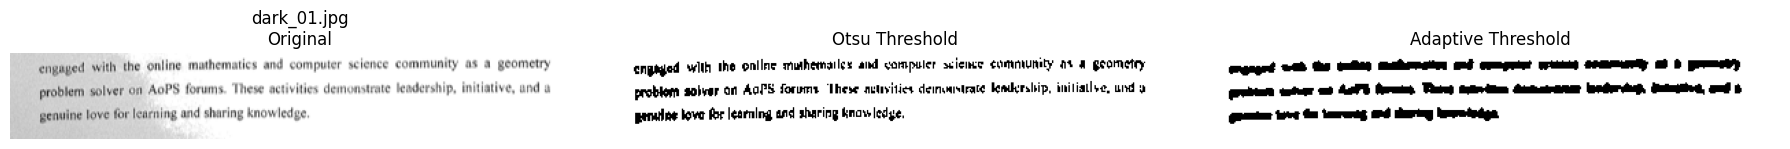

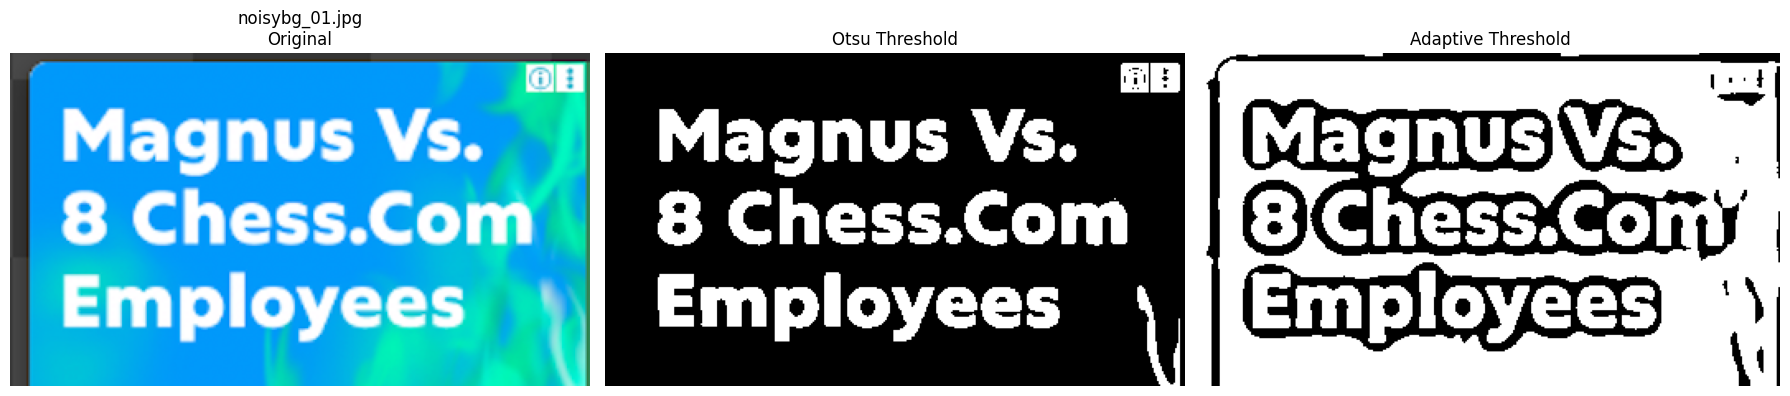

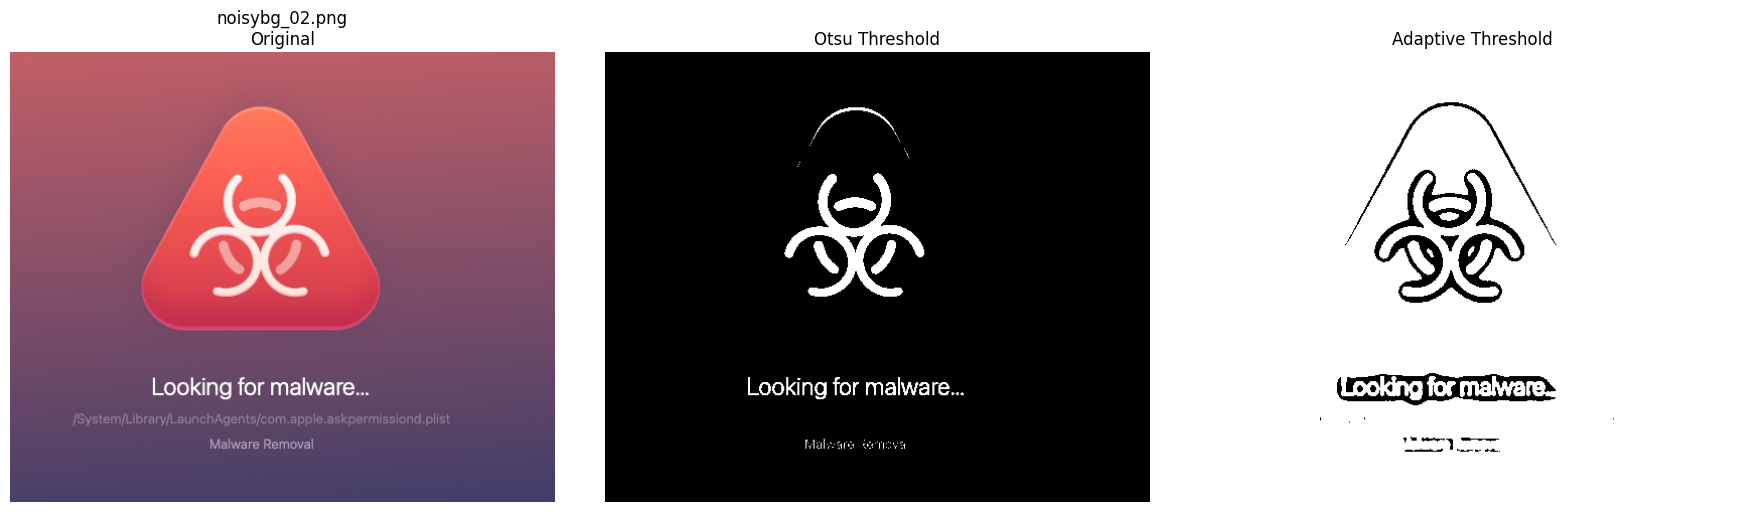

In [ ]:
#Compare again
for result in adaptive_results:
    filename = result["filename"]
    stem = Path(filename).stem

    otsu_path = OTSU_DIR / f"{stem}_otsu.png"
    otsu = cv2.imread(str(otsu_path), cv2.IMREAD_GRAYSCALE)

    plt.figure(figsize=(18, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(result["original"])
    plt.title(f"{filename}\nOriginal")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(otsu, cmap="gray")
    plt.title("Otsu Threshold")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(result["adaptive"], cmap="gray")
    plt.title("Adaptive Threshold")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

In [ ]:
cv03_results = []

for result in adaptive_results:
    filename = result["filename"]
    stem = Path(filename).stem

    original_path = INPUT_DIR / filename
    otsu_path = OTSU_DIR / f"{stem}_otsu.png"
    adaptive_path = result["output_path"]

    original_text = run_ocr(original_path)
    otsu_text = run_ocr(otsu_path)
    adaptive_text = run_ocr(adaptive_path)

    cv03_results.append({
        "Image Name": filename,
        "OCR Original": original_text,
        "OCR Otsu": otsu_text,
        "OCR Adaptive": adaptive_text,
        "Best Version": "",
        "Observation": ""
    })

    print("=" * 80)
    print("IMAGE:", filename)

    print("\n[Original OCR]")
    print(original_text)

    print("\n[Otsu OCR]")
    print(otsu_text)

    print("\n[Adaptive OCR]")
    print(adaptive_text)

cv03_df = pd.DataFrame(cv03_results)
cv03_df

IMAGE: dark_01.jpg

[Original OCR]
‘engaged with the online mathematics and computer science community as a geometry
problem solver on AoPS forums. These atvtes demonstrate leadership, inative, and a
genie love fr artng and sharing knowledge

[Otsu OCR]
‘engaged with the online muthemnailex and vornpuier sciewe community as a geometry
problem salvar cn AGP forums These netnities densa Iendrsip, initials, und 9
rude eve fr letening ar sharing kro ede,

[Adaptive OCR]
renert wah ths entien makes ont compiet wees SommENy ab b pe)
preteen wher mt AoE fan, The) eivine amaranae oder. Dane ot
om te a reg arg wetntge,
IMAGE: noisybg_01.jpg

[Original OCR]
Magnus Vs. y
8 Chess.Com
Employees y

[Otsu OCR]
8
Magnus Vs.
8 Chess.Com
Employees ry

[Adaptive OCR]
ee
'S\Chess.Conim
Employees >
IMAGE: noisybg_02.png

[Original OCR]
a Os
Looking for malware...
DE aud

[Otsu OCR]
—_
om
Ly
Looking for malware...
ree ee oa a

[Adaptive OCR]
#


,Image Name,OCR Original,OCR Otsu,OCR Adaptive,Best Version,Observation
0,dark_01.jpg,‘engaged with the online mathematics and compu...,‘engaged with the online muthemnailex and vorn...,renert wah ths entien makes ont compiet wees S...,,
1,noisybg_01.jpg,Magnus Vs. y\n8 Chess.Com\nEmployees y,8\nMagnus Vs.\n8 Chess.Com\nEmployees ry,ee\n'S\Chess.Conim\nEmployees >,,
2,noisybg_02.png,a Os\nLooking for malware...\nDE aud,—_\nom\nLy\nLooking for malware...\nree ee oa a,#,,


In [ ]:
#For blur
SHARPEN_DIR = OUTPUT_DIR / "sharpening"
SHARPEN_DIR.mkdir(parents=True, exist_ok=True)

print("Sharpen output folder:", SHARPEN_DIR)

Sharpen output folder: /content/drive/MyDrive/FPT AI Intern Prep/CV OCR Project/output_images/sharpening


In [ ]:
import numpy as np

def sharpen_image(image_path: Path, target_width: int = 1000):
    image_bgr = cv2.imread(str(image_path))

    if image_bgr is None:
        raise FileNotFoundError(f"Cant read: {image_path}")

    height, width = image_bgr.shape[:2]

    if width > target_width:
        scale = target_width / width
        new_height = int(height * scale)
        image_bgr = cv2.resize(
            image_bgr,
            (target_width, new_height),
            interpolation=cv2.INTER_AREA
        )

    gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)

    # Blur reduce
    denoised = cv2.GaussianBlur(gray, (3, 3), 0)

    # Kernel sharpen
    kernel = np.array([
        [0, -1,  0],
        [-1, 5, -1],
        [0, -1,  0]
    ])

    sharpened = cv2.filter2D(denoised, -1, kernel)

    output_path = SHARPEN_DIR / f"{image_path.stem}_sharpened.png"
    cv2.imwrite(str(output_path), sharpened)

    return sharpened, output_path

Saved: /content/drive/MyDrive/FPT AI Intern Prep/CV OCR Project/output_images/sharpening/blur_01_sharpened.png


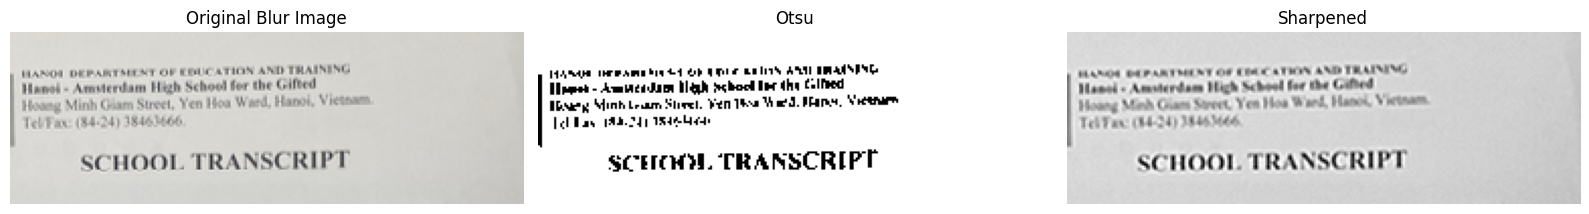

In [ ]:
#Run for blur image
blur_path = INPUT_DIR / "blur_01.jpg"

sharpened_image, sharpened_path = sharpen_image(blur_path)

print("Saved:", sharpened_path)

plt.figure(figsize=(16, 5))

original_bgr = cv2.imread(str(blur_path))
original_rgb = cv2.cvtColor(original_bgr, cv2.COLOR_BGR2RGB)

otsu_blur = cv2.imread(
    str(OTSU_DIR / "blur_01_otsu.png"),
    cv2.IMREAD_GRAYSCALE
)

plt.subplot(1, 3, 1)
plt.imshow(original_rgb)
plt.title("Original Blur Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(otsu_blur, cmap="gray")
plt.title("Otsu")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(sharpened_image, cmap="gray")
plt.title("Sharpened")
plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
original_text = run_ocr(INPUT_DIR / "blur_01.jpg")
otsu_text = run_ocr(OTSU_DIR / "blur_01_otsu.png")
sharpened_text = run_ocr(sharpened_path)

print("===== ORIGINAL OCR =====")
print(original_text)

print("\n===== OTSU OCR =====")
print(otsu_text)

print("\n===== SHARPENED OCR =====")
print(sharpened_text)

===== ORIGINAL OCR =====
a

===== OTSU OCR =====
| fino Rei ig wctined R
SCHOON. TRANSCRIPT

===== SHARPENED OCR =====
| ioe ec ca
SCHOOL TRANSCRIPT
